# 01 — Data cleaning and engineering
Lisbon Airbnb Market Intelligence | Expernetic Data Engineer Intern Assignment

Purpose: Generate key visualizations, test statistical hypotheses and prepare insights for Power BI dashboard

In [1]:
# 03_exploratory_data_analysis.ipynb

# Lisbon Airbnb Market Intelligence - EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up paths
project_root = Path.cwd().parent
PROCESSED = project_root / "data" / "processed"
OUTPUT = project_root / "reports" / "figures"
OUTPUT.mkdir(parents=True, exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*60)
print("PHASE 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# ============================================
# 1. LOAD CLEANED DATA
# ============================================
print("\n[1] Loading cleaned data...")

final_df = pd.read_csv(PROCESSED / "listings_enriched.csv", 
                       parse_dates=['first_review_date', 'last_review_date'])

print(f" Loaded {len(final_df):,} listings")
print(f" Columns: {final_df.columns.tolist()}")



PHASE 3: EXPLORATORY DATA ANALYSIS

[1] Loading cleaned data...
 Loaded 24,876 listings
 Columns: ['listing_id', 'listing_name', 'host_id', 'host_name', 'host_tenure_years', 'is_superhost', 'host_total_listings', 'neighbourhood', 'neighbourhood_group', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'price', 'price_per_bedroom', 'min_nights', 'max_nights', 'availability_365', 'occupancy_rate', 'estimated_revenue', 'review_count', 'review_score', 'first_review_date', 'last_review_date']



[2] Price Analysis...


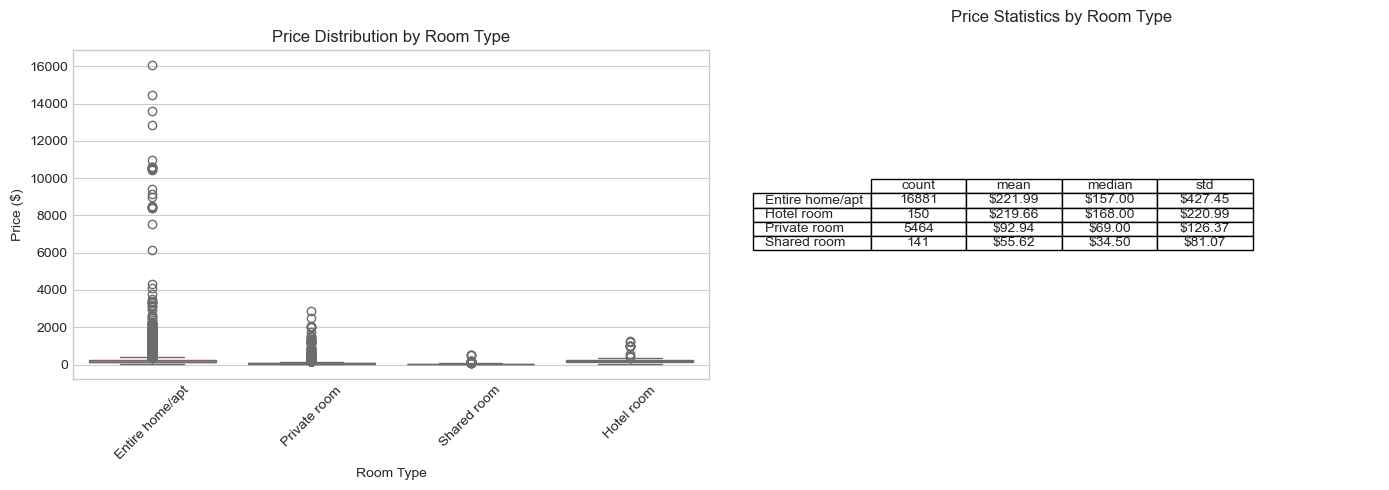

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\price_by_room_type.png


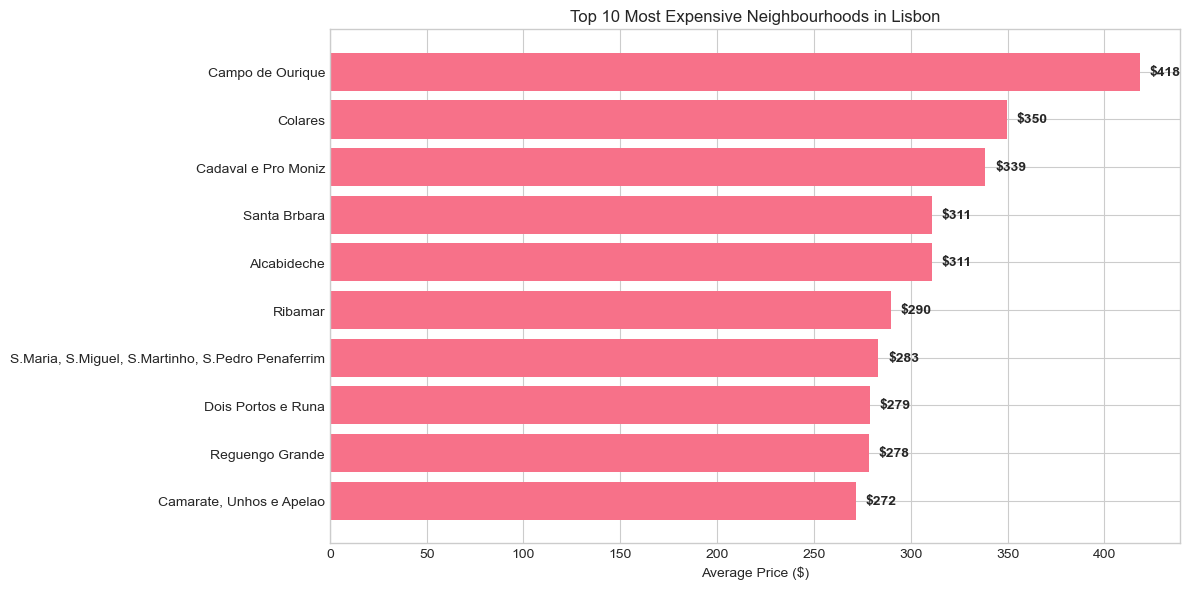

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\top_neighbourhoods_price.png


In [2]:
# ============================================
# 2. PRICE ANALYSIS
# ============================================
print("\n[2] Price Analysis...")

# 2.1 Price distribution by room type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=final_df, x='room_type', y='price', ax=axes[0])
axes[0].set_title('Price Distribution by Room Type')
axes[0].set_ylabel('Price ($)')
axes[0].set_xlabel('Room Type')
axes[0].tick_params(axis='x', rotation=45)

# Summary statistics table
room_type_stats = final_df.groupby('room_type')['price'].agg(['count', 'mean', 'median', 'std']).round(2)
room_type_stats['mean'] = room_type_stats['mean'].map('${:,.2f}'.format)
room_type_stats['median'] = room_type_stats['median'].map('${:,.2f}'.format)
room_type_stats['std'] = room_type_stats['std'].map('${:,.2f}'.format)

# Create a table visualization
ax2 = axes[1]
ax2.axis('tight')
ax2.axis('off')
table = ax2.table(cellText=room_type_stats.values,
                  colLabels=room_type_stats.columns,
                  rowLabels=room_type_stats.index,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
ax2.set_title('Price Statistics by Room Type', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT / 'price_by_room_type.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'price_by_room_type.png'}")

# 2.2 Top 10 most expensive neighbourhoods
neighbourhood_price = final_df.groupby('neighbourhood')['price'].agg(['mean', 'count']).round(2)
neighbourhood_price = neighbourhood_price[neighbourhood_price['count'] >= 10]  # Minimum 10 listings
neighbourhood_price = neighbourhood_price.sort_values('mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(neighbourhood_price.index, neighbourhood_price['mean'])
ax.set_xlabel('Average Price ($)')
ax.set_title('Top 10 Most Expensive Neighbourhoods in Lisbon')
ax.invert_yaxis()

# Add value labels
for i, (bar, value) in enumerate(zip(bars, neighbourhood_price['mean'])):
    ax.text(value + 5, bar.get_y() + bar.get_height()/2, f'${value:,.0f}', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT / 'top_neighbourhoods_price.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'top_neighbourhoods_price.png'}")




[3] Superhost Analysis...


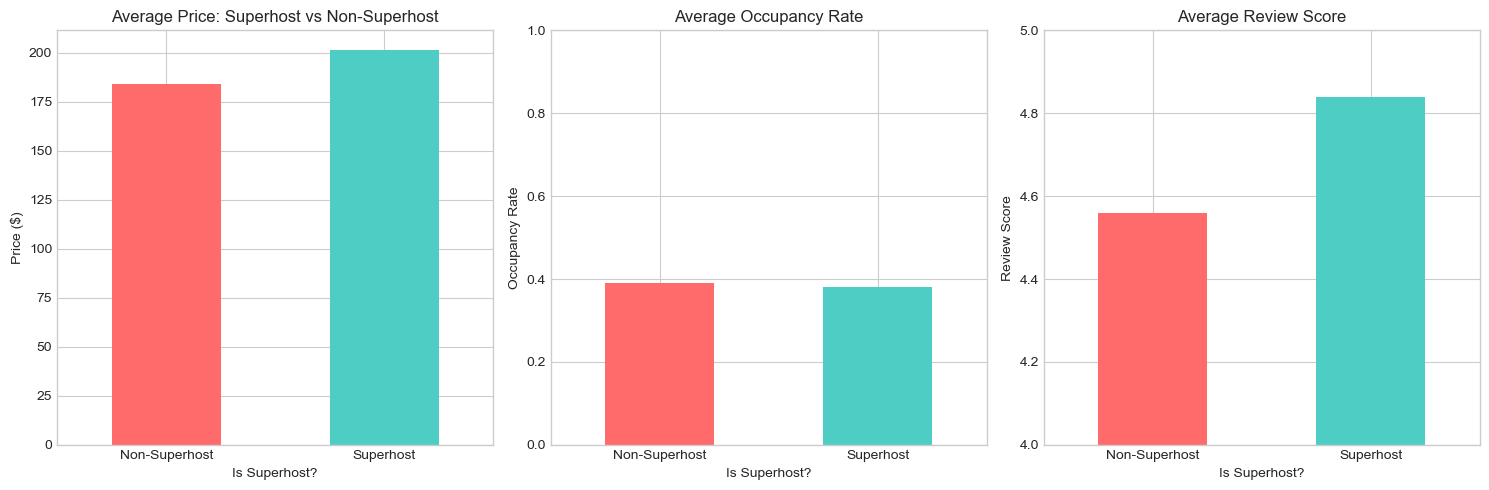

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\superhost_comparison.png

 Superhost Comparison Table:
              Avg Price  Median Price  Avg Occupancy  Avg Review Score  Count
is_superhost                                                                 
f                183.95        127.00           0.39              4.56  16881
t                201.42        150.07           0.38              4.84   7975


In [3]:
# ============================================
# 3. SUPERHOST ANALYSIS
# ============================================
print("\n[3] Superhost Analysis...")

superhost_comparison = final_df.groupby('is_superhost').agg({
    'price': ['mean', 'median'],
    'occupancy_rate': 'mean',
    'review_score': 'mean',
    'listing_id': 'count'
}).round(2)

superhost_comparison.columns = ['Avg Price', 'Median Price', 'Avg Occupancy', 'Avg Review Score', 'Count']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Price comparison
superhost_comparison['Avg Price'].plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Average Price: Superhost vs Non-Superhost')
axes[0].set_ylabel('Price ($)')
axes[0].set_xlabel('Is Superhost?')
axes[0].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0)

# Occupancy comparison
superhost_comparison['Avg Occupancy'].plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Average Occupancy Rate')
axes[1].set_ylabel('Occupancy Rate')
axes[1].set_xlabel('Is Superhost?')
axes[1].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0)
axes[1].set_ylim(0, 1)

# Review score comparison
superhost_comparison['Avg Review Score'].plot(kind='bar', ax=axes[2], color=['#ff6b6b', '#4ecdc4'])
axes[2].set_title('Average Review Score')
axes[2].set_ylabel('Review Score')
axes[2].set_xlabel('Is Superhost?')
axes[2].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0)
axes[2].set_ylim(4, 5)

plt.tight_layout()
plt.savefig(OUTPUT / 'superhost_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'superhost_comparison.png'}")

print("\n Superhost Comparison Table:")
print(superhost_comparison)




[4] Host Portfolio Analysis...


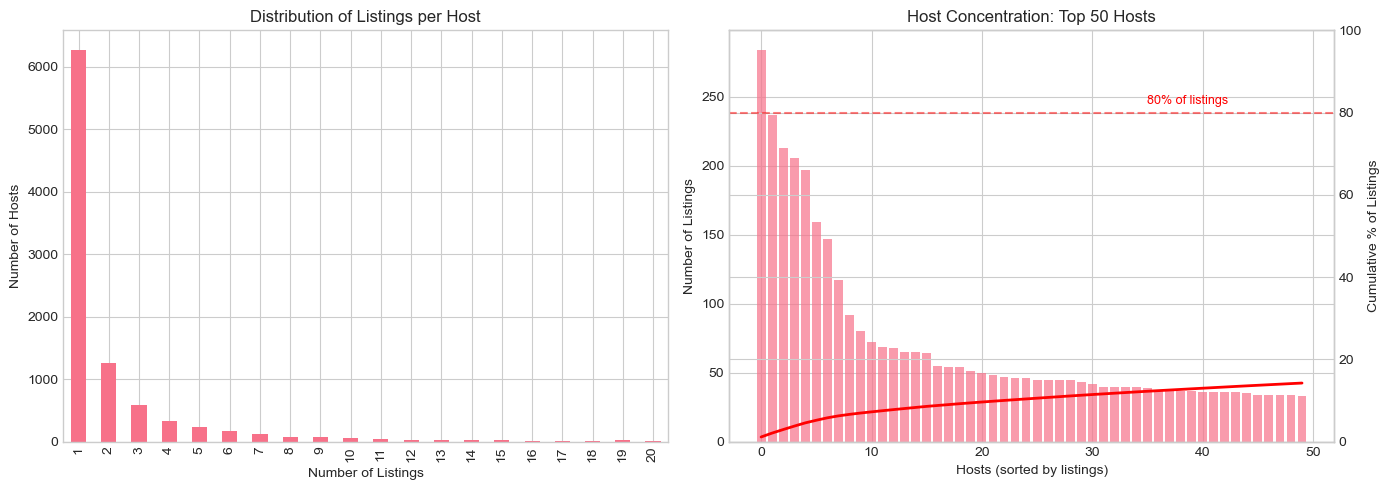

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\host_portfolio.png

 Host Concentration:
  - Total Hosts: 9,521
  - Hosts with 1 listing: 6,272 (65.9%)
  - Top 10% of hosts control 49.9% of listings
  - Max listings by single host: 284


In [4]:
# ============================================
# 4. HOST PORTFOLIO ANALYSIS (Power Law)
# ============================================
print("\n[4] Host Portfolio Analysis...")

host_listings = final_df.groupby('host_id').size().sort_values(ascending=False)
host_listings_dist = host_listings.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
host_listings_dist.head(20).plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of Listings per Host')
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('Number of Hosts')

# Pareto chart (cumulative percentage)
host_listings_sorted = host_listings.sort_values(ascending=False)
cumulative_pct = (host_listings_sorted.cumsum() / host_listings_sorted.sum() * 100).head(50)

ax2 = axes[1]
ax2.bar(range(len(host_listings_sorted.head(50))), host_listings_sorted.head(50), alpha=0.7)
ax2.set_xlabel('Hosts (sorted by listings)')
ax2.set_ylabel('Number of Listings')
ax2.set_title('Host Concentration: Top 50 Hosts')

# Add cumulative line
ax3 = ax2.twinx()
ax3.plot(range(len(cumulative_pct)), cumulative_pct, 'r-', linewidth=2, label='Cumulative %')
ax3.set_ylabel('Cumulative % of Listings')
ax3.set_ylim(0, 100)

# Add 80% line
ax3.axhline(y=80, color='r', linestyle='--', alpha=0.5)
ax3.text(35, 82, '80% of listings', color='r', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT / 'host_portfolio.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'host_portfolio.png'}")

# Calculate concentration metrics
top_10_pct_hosts = int(len(host_listings) * 0.10)
listings_by_top_10 = host_listings_sorted.head(top_10_pct_hosts).sum()
print(f"\n Host Concentration:")
print(f"  - Total Hosts: {len(host_listings):,}")
print(f"  - Hosts with 1 listing: {(host_listings == 1).sum():,} ({((host_listings == 1).sum() / len(host_listings) * 100):.1f}%)")
print(f"  - Top 10% of hosts control {listings_by_top_10 / host_listings.sum() * 100:.1f}% of listings")
print(f"  - Max listings by single host: {host_listings.max():,}")




[5] Price vs Occupancy Relationship...


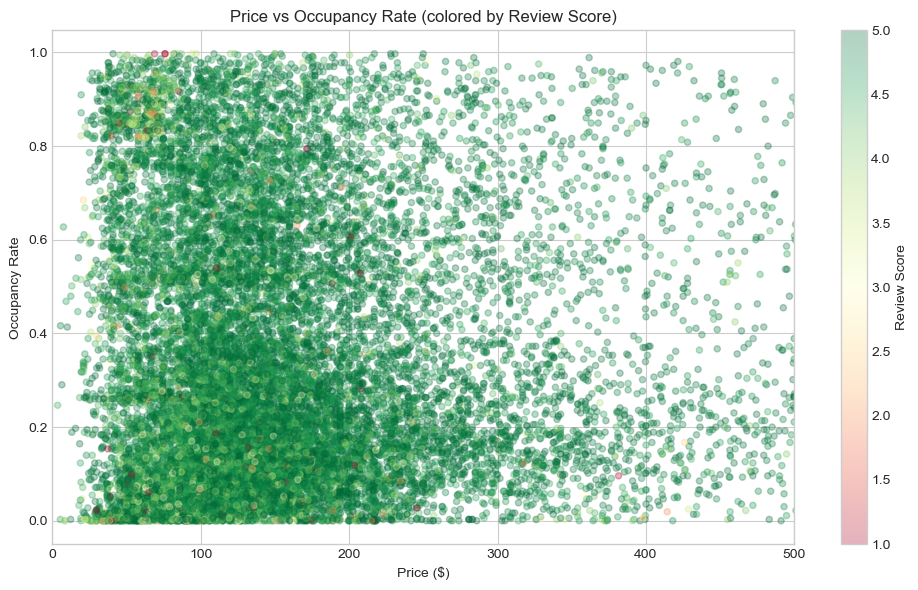

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\price_vs_occupancy.png

 Correlation Matrix:
                   price  occupancy_rate  review_score  bedrooms  accommodates
price           1.000000       -0.018911     -0.018203  0.307414      0.314361
occupancy_rate -0.018911        1.000000     -0.012881  0.034409     -0.032369
review_score   -0.018203       -0.012881      1.000000  0.040672      0.086256
bedrooms        0.307414        0.034409      0.040672  1.000000      0.763961
accommodates    0.314361       -0.032369      0.086256  0.763961      1.000000


In [5]:
# ============================================
# 5. PRICE VS OCCUPANCY
# ============================================
print("\n[5] Price vs Occupancy Relationship...")

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(final_df['price'], final_df['occupancy_rate'], 
                     alpha=0.3, c=final_df['review_score'], cmap='RdYlGn', s=20)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Occupancy Rate')
ax.set_title('Price vs Occupancy Rate (colored by Review Score)')
ax.set_xlim(0, 500)  # Focus on main range

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Review Score')

plt.tight_layout()
plt.savefig(OUTPUT / 'price_vs_occupancy.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'price_vs_occupancy.png'}")

# Correlation
correlation = final_df[['price', 'occupancy_rate', 'review_score', 'bedrooms', 'accommodates']].corr()
print("\n Correlation Matrix:")
print(correlation)



In [6]:
# ============================================
# 6. STATISTICAL HYPOTHESIS TESTS
# ============================================
print("\n[6] Statistical Hypothesis Tests...")

from scipy import stats

# H1: Superhosts have higher prices
superhost_prices = final_df[final_df['is_superhost'] == 't']['price'].dropna()
nonsuperhost_prices = final_df[final_df['is_superhost'] != 't']['price'].dropna()

t_stat, p_value = stats.ttest_ind(superhost_prices, nonsuperhost_prices, equal_var=False)
effect_size = (superhost_prices.mean() - nonsuperhost_prices.mean()) / nonsuperhost_prices.std()

print(f"\n H1: Superhosts have higher prices")
print(f"  - Superhost mean: ${superhost_prices.mean():.2f}")
print(f"  - Non-Superhost mean: ${nonsuperhost_prices.mean():.2f}")
print(f"  - Difference: ${superhost_prices.mean() - nonsuperhost_prices.mean():.2f}")
print(f"  - t-statistic: {t_stat:.3f}")
print(f"  - p-value: {p_value:.5f}")
print(f"  - Effect size (Cohen's d): {effect_size:.3f}")
if p_value < 0.05:
    print(f"   Statistically significant at α=0.05")
else:
    print(f"   Not statistically significant")

# H2: Entire homes cost more than private rooms
entire_home = final_df[final_df['room_type'] == 'Entire home/apt']['price'].dropna()
private_room = final_df[final_df['room_type'] == 'Private room']['price'].dropna()

t_stat2, p_value2 = stats.ttest_ind(entire_home, private_room, equal_var=False)
effect_size2 = (entire_home.mean() - private_room.mean()) / private_room.std()

print(f"\n H2: Entire homes cost more than private rooms")
print(f"  - Entire home mean: ${entire_home.mean():.2f}")
print(f"  - Private room mean: ${private_room.mean():.2f}")
print(f"  - Difference: ${entire_home.mean() - private_room.mean():.2f}")
print(f"  - t-statistic: {t_stat2:.3f}")
print(f"  - p-value: {p_value2:.5f}")
print(f"  - Effect size (Cohen's d): {effect_size2:.3f}")
if p_value2 < 0.05:
    print(f"   Statistically significant at α=0.05")
else:
    print(f"   Not statistically significant")




[6] Statistical Hypothesis Tests...

 H1: Superhosts have higher prices
  - Superhost mean: $201.42
  - Non-Superhost mean: $183.89
  - Difference: $17.53
  - t-statistic: 3.771
  - p-value: 0.00016
  - Effect size (Cohen's d): 0.041
   Statistically significant at α=0.05

 H2: Entire homes cost more than private rooms
  - Entire home mean: $221.99
  - Private room mean: $92.94
  - Difference: $129.05
  - t-statistic: 34.807
  - p-value: 0.00000
  - Effect size (Cohen's d): 1.021
   Statistically significant at α=0.05



[7] Geographic Insights...


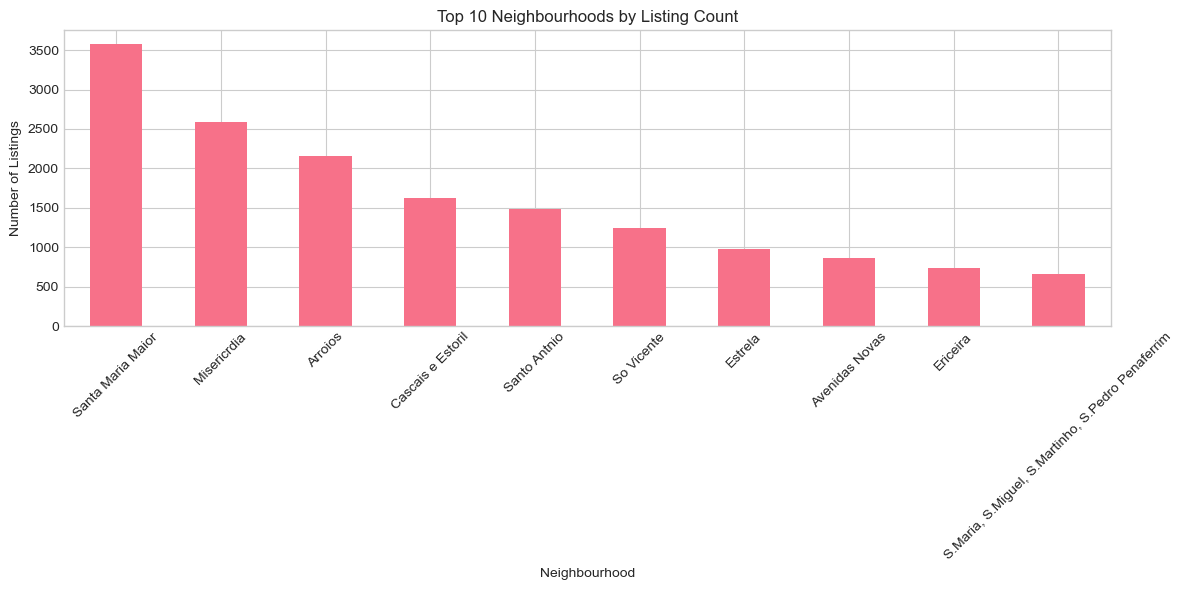

 Saved to C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures\top_neighbourhoods_listings.png


In [7]:
# ============================================
# 7. GEOGRAPHIC INSIGHTS
# ============================================
print("\n[7] Geographic Insights...")

# Top neighbourhoods by listing count
top_neighbourhoods = final_df['neighbourhood'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_neighbourhoods.plot(kind='bar', ax=ax)
ax.set_title('Top 10 Neighbourhoods by Listing Count')
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('Number of Listings')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT / 'top_neighbourhoods_listings.png', dpi=300, bbox_inches='tight')
plt.show()
print(f" Saved to {OUTPUT / 'top_neighbourhoods_listings.png'}")



In [9]:
# ============================================
# 8. SUMMARY (FIXED)
# ============================================
print("\n" + "="*60)
print("EDA SUMMARY")
print("="*60)

# Define the variables we need for the summary
superhost_data = final_df[final_df['is_superhost'] == 't']
nonsuperhost_data = final_df[final_df['is_superhost'] != 't']

# Get host portfolio data again if needed
host_listings = final_df.groupby('host_id').size().sort_values(ascending=False)
host_listings_sorted = host_listings.sort_values(ascending=False)
top_10_pct_hosts = int(len(host_listings) * 0.10)
listings_by_top_10 = host_listings_sorted.head(top_10_pct_hosts).sum()

# Get superhost prices for the premium calculation
superhost_prices = final_df[final_df['is_superhost'] == 't']['price'].dropna()
nonsuperhost_prices = final_df[final_df['is_superhost'] != 't']['price'].dropna()

print(f"""
 Key Findings:

1. Price Analysis:
   - Average price: ${final_df['price'].mean():.2f}
   - Median price: ${final_df['price'].median():.2f}
   - Most expensive room type: {final_df.groupby('room_type')['price'].mean().idxmax()} (${final_df.groupby('room_type')['price'].mean().max():.2f})
   - Cheapest room type: {final_df.groupby('room_type')['price'].mean().idxmin()} (${final_df.groupby('room_type')['price'].mean().min():.2f})

2. Superhost Effect:
   - Price premium: +{((superhost_prices.mean()/nonsuperhost_prices.mean())-1)*100:.1f}%
   - Occupancy premium: +{(superhost_data['occupancy_rate'].mean() - nonsuperhost_data['occupancy_rate'].mean()) * 100:.1f}%
   - Review score premium: +{(superhost_data['review_score'].mean() - nonsuperhost_data['review_score'].mean()):.2f} points

3. Market Concentration:
   - {(host_listings == 1).sum() / len(host_listings) * 100:.1f}% of hosts have only 1 listing
   - Top 10% of hosts control {listings_by_top_10 / host_listings.sum() * 100:.1f}% of listings

4. Occupancy:
   - Average occupancy: {final_df['occupancy_rate'].mean():.2%}
   - {len(final_df[final_df['occupancy_rate'] > 0.8]):,} listings have >80% occupancy
""")

print(f"\n EDA completed successfully!")
print(f" Figures saved to: {OUTPUT}")
print(f" Use these insights for your Power BI dashboard!")


EDA SUMMARY

 Key Findings:

1. Price Analysis:
   - Average price: $189.79
   - Median price: $136.00
   - Most expensive room type: Entire home/apt ($221.99)
   - Cheapest room type: Shared room ($55.62)

2. Superhost Effect:
   - Price premium: +9.5%
   - Occupancy premium: +-1.1%
   - Review score premium: +0.27 points

3. Market Concentration:
   - 65.9% of hosts have only 1 listing
   - Top 10% of hosts control 49.9% of listings

4. Occupancy:
   - Average occupancy: 38.70%
   - 4,045 listings have >80% occupancy


 EDA completed successfully!
 Figures saved to: C:\Users\User\Documents\GitHub\expernetic-data-engineer-assessment\reports\figures
 Use these insights for your Power BI dashboard!
